# DeepVRegulome — Attention Visualization & Motif Analysis

This notebook demonstrates DeepVRegulome's interpretability features: extracting DNABERT
attention weights to understand **why** a variant disrupts TF binding.

**What you'll learn:**
1. Score variants with attention extraction (`return_attention=True`)
2. Interpret attention summary metrics in the output DataFrame
3. Access position-level attention data with `dvr.get_attention()`
4. Visualize attention patterns with `dvr.plot_attention()` and `dvr.plot_attention_heatmap()`
5. Custom attention analysis: find the most disrupted positions

**Prerequisites:**
- `pip install deepvregulome[all]`
- Reference genome FASTA (hg38)

**Background:** DNABERT has 12 transformer layers, each with multiple attention heads.
Attention weights reveal which k-mer positions the model "focuses on" when making binding
predictions. By comparing attention between REF and ALT sequences, we can identify the
specific positions and motifs that are disrupted by a variant.

## 1. Setup

In [1]:
from deepvregulome import DVR
import numpy as np
import pandas as pd
import torch

# ⚠️ Update this path
GENOME = "/data/projects/human_reference_genome/hg38/all_chr_ref.fasta"

dvr = DVR(genome=GENOME)

---
## 2. Score a Variant with Attention

Setting `return_attention=True` adds attention-based columns to the output and stores
position-level attention data in `dvr.last_attention`.

**Additional output columns with attention:**

| Column | Meaning |
|--------|---------|
| `attention_score_change` | L2 norm of attention difference across all 12 layers. Higher = model focuses on different positions after mutation |
| `max_attention_shift` | Largest single-position attention weight change across all layers |
| `disrupted_layers` | Number of BERT layers where mean attention change exceeds threshold |
| `total_layers` | Always 12 (DNABERT-base architecture) |

In [2]:
# Score with attention extraction
result = dvr.score_variant(
    chrom="chr9",
    pos=65385776,
    ref="G",
    alt="A",
    models=["ATF4", "CTCFL"],
    return_attention=True,
)

# Display all columns (transposed for readability)
result.T

⚠ Sanity check: likely 1-based but not fully certain
  Checked 1 variants: 1 suggest 1-based, 0 suggest 0-based, 0 ambiguous, 0 no-match
  Proceeding with 1-based. Override with coordinate_system= if needed.


Models:   0%|          | 0/2 [00:00<?, ?model/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  ATF4:   0%|          | 0/1 [00:00<?, ?batch/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  CTCFL:   0%|          | 0/1 [00:00<?, ?batch/s]

,0,1
chrom,chr9,chr9
pos,65385776,65385776
ref,G,G
alt,A,A
model,ATF4,CTCFL
type,TF,TF
prob_ref,0.999954,0.323819
prob_alt,0.102366,0.870792
log_odds_ratio,17.5287,-3.8149
score_change,-0.897546,0.4763


**Interpreting ATF4 results:**
- `prob_ref ≈ 1.0`, `prob_alt ≈ 0.1` → strong binding lost after G>A mutation
- `attention_score_change` measures how much the model's overall focus pattern changed
- `max_attention_shift` shows the peak disruption at any single position

---
## 3. Access Position-Level Attention Data

After scoring with `return_attention=True`, raw attention data is available
via `dvr.get_attention(model_name)`.

In [3]:
# Get attention data for ATF4
attn = dvr.get_attention("ATF4")

print("Available keys:", list(attn.keys()))
print(f"REF attention shape: {attn['ref_attention'].shape}")    # [seq_len] — averaged across layers and heads
print(f"ALT attention shape: {attn['alt_attention'].shape}")    # [seq_len]
print(f"Diff attention shape: {attn['diff_attention'].shape}")  # [seq_len]
print(f"Variant position in window: {attn['variant_pos']}")
print(f"REF sequence length: {len(attn['ref_seq'])}")
print(f"P(binding) REF: {attn['prob_ref']:.4f}")
print(f"P(binding) ALT: {attn['prob_alt']:.4f}")

Available keys: ['ref_attention', 'alt_attention', 'diff_attention', 'ref_raw', 'alt_raw', 'ref_seq', 'alt_seq', 'prob_ref', 'prob_alt', 'variant_pos', 'chrom', 'genomic_pos']
REF attention shape: (298,)
ALT attention shape: (298,)
Diff attention shape: (298,)
Variant position in window: 150
REF sequence length: 301
P(binding) REF: 1.0000
P(binding) ALT: 0.1024


In [4]:
# Raw attention tensors (for advanced analysis)
print(f"Raw REF tensor shape: {attn['ref_raw'].shape}")  # [12 layers, heads, seq_len, seq_len]
print(f"Raw ALT tensor shape: {attn['alt_raw'].shape}")  # same

Raw REF tensor shape: (12, 12, 298, 298)
Raw ALT tensor shape: (12, 12, 298, 298)


---
## 4. Visualize Attention Patterns

DVR provides two built-in visualization methods:
- `dvr.plot_attention()` — bar chart showing REF vs ALT attention around the variant
- `dvr.plot_attention_heatmap()` — layer × position heatmap showing which layers are disrupted

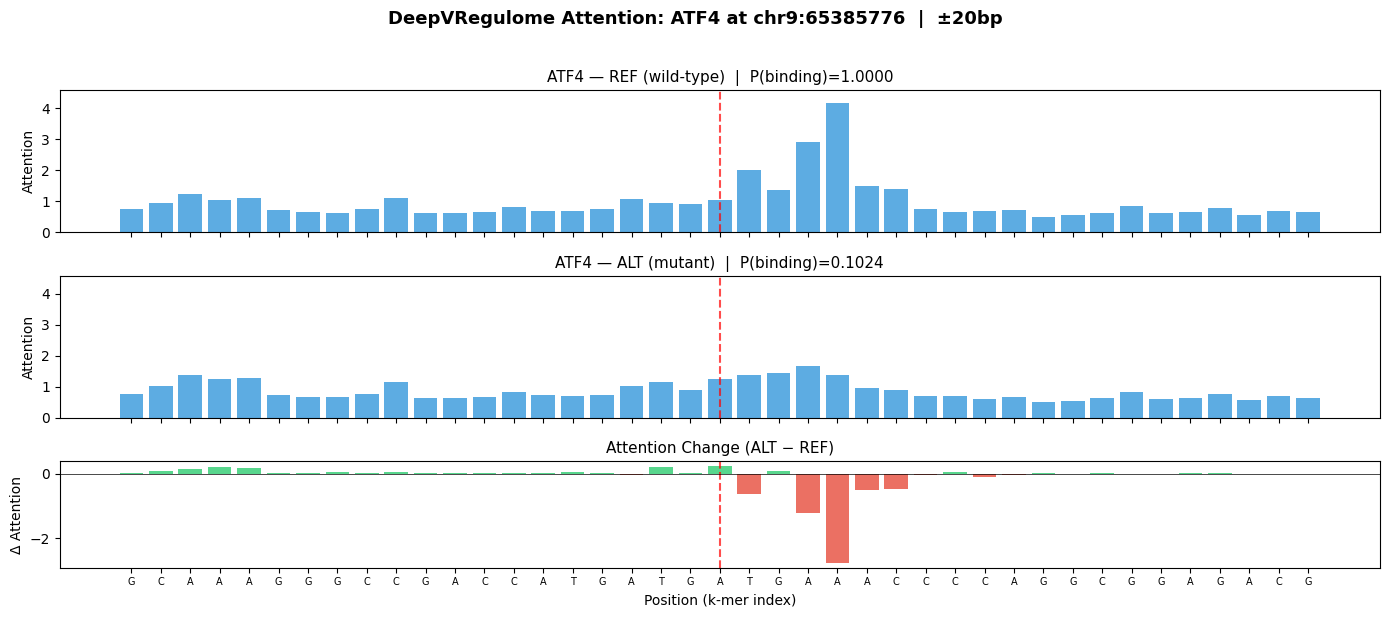

In [5]:
# Bar chart: REF vs ALT attention (±20bp window around variant)
fig = dvr.plot_attention("ATF4", window=20)

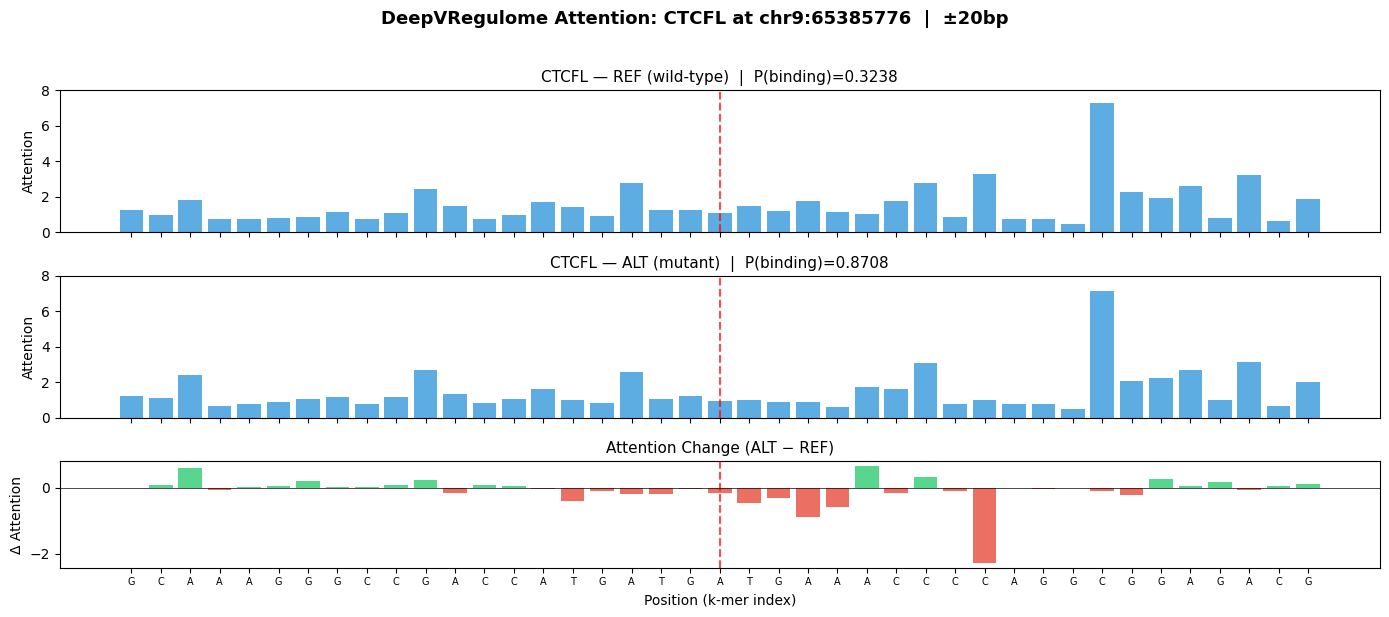

In [7]:
# Compare: attention pattern for CTCFL (same variant, different model)
fig = dvr.plot_attention("CTCFL", window=20)

**Reading the bar chart:**
- **Top panel (blue):** where the model focuses on the REF (wild-type) sequence
- **Middle panel (red):** where the model focuses on the ALT (mutant) sequence
- **Bottom panel (red/green):** the difference — red bars show positions that LOST attention after mutation
- **Dashed vertical line:** variant position

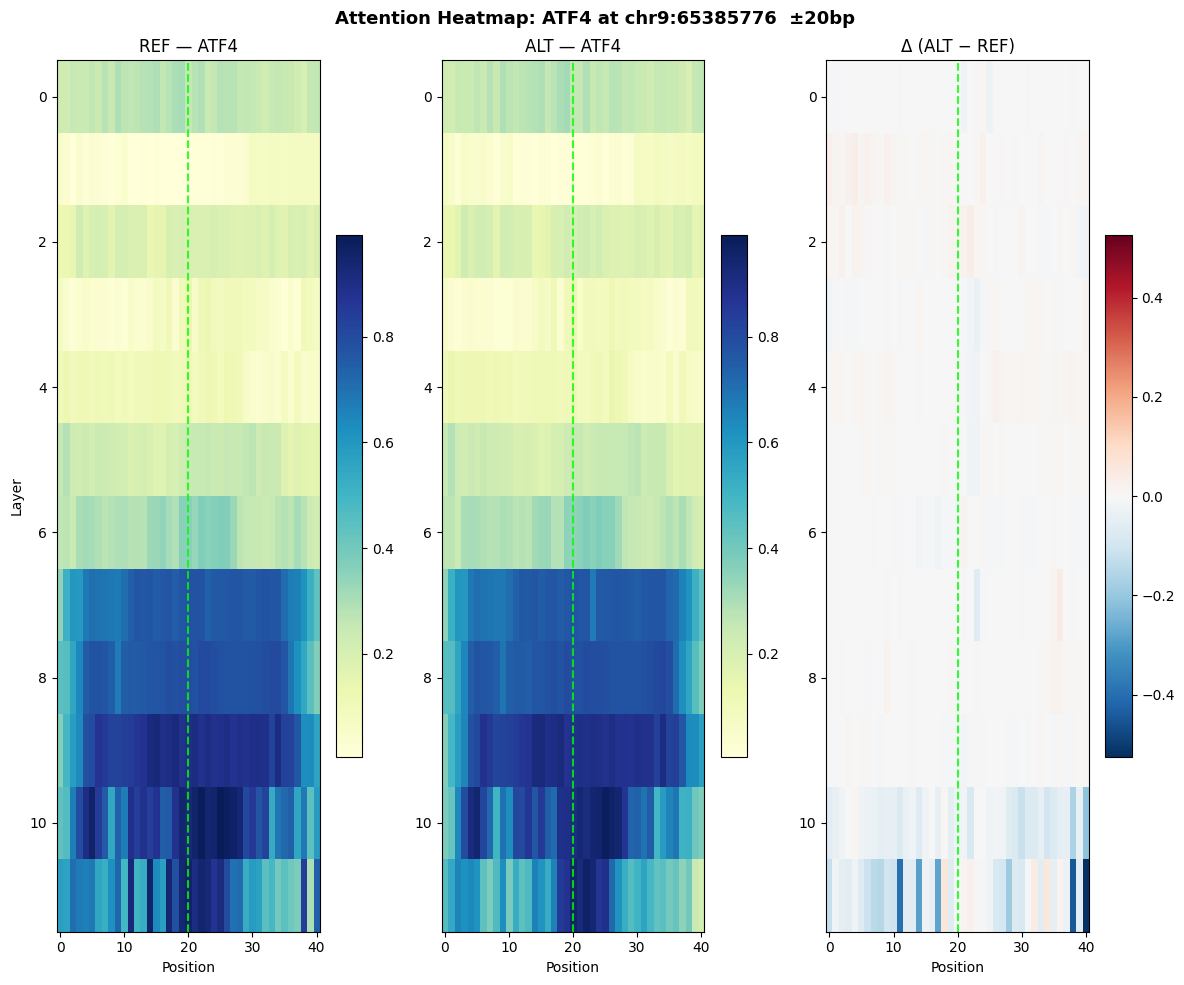

In [8]:
# Layer × Position heatmap
fig = dvr.plot_attention_heatmap("ATF4", window=20)

**Reading the heatmap:**
- Each row is one of DNABERT's 12 transformer layers
- Columns are positions around the variant
- The difference panel shows which layers × positions are most disrupted
- Green dashed line marks the variant position

In [ ]:
# Save plots to files
dvr.plot_attention("ATF4", window=20, save_path="ATF4_attention_barplot.png")
dvr.plot_attention_heatmap("ATF4", window=20, save_path="ATF4_attention_heatmap.png")
print("Saved: ATF4_attention_barplot.png, ATF4_attention_heatmap.png")

---
## 5. Custom Attention Analysis

Using the raw attention data, you can perform your own analyses — for example,
finding the most disrupted positions or comparing attention patterns across multiple variants.

In [9]:
# Find the top 10 most disrupted positions
attn = dvr.get_attention("ATF4")
diff = attn["diff_attention"]
variant_pos = attn["variant_pos"]
ref_seq = attn["ref_seq"]

top_positions = np.argsort(np.abs(diff))[::-1][:10]

print(f"Top 10 disrupted positions (variant at position {variant_pos}):")
print(f"{'Position':>10} {'Offset':>8} {'Base':>6} {'Δ Attention':>14}")
print("-" * 42)
for pos in top_positions:
    offset = pos - variant_pos
    base = ref_seq[pos] if pos < len(ref_seq) else "?"
    print(f"{pos:>10} {offset:>+8} {base:>6} {diff[pos]:>14.6f}")

Top 10 disrupted positions (variant at position 150):
  Position   Offset   Base    Δ Attention
------------------------------------------
       149       -1      T      -2.769650
       148       -2      A      -1.231636
       146       -4      T      -0.632467
       150       +0      G      -0.514734
         1     -149      T      -0.505171
       151       +1      A      -0.482920
        69      -81      G      -0.380118
         0     -150      T       0.225357
       145       -5      A       0.225155
       143       -7      T       0.211743


In [10]:
# Analyze disruption by DNABERT layer
# Raw shape: [12 layers, heads, seq_len, seq_len]
ref_raw = attn["ref_raw"]
alt_raw = attn["alt_raw"]

# Mean attention per layer (average across heads and positions)
for layer in range(12):
    ref_layer = ref_raw[layer].mean()
    alt_layer = alt_raw[layer].mean()
    layer_diff = abs(ref_layer - alt_layer)
    print(f"Layer {layer:>2}: REF mean={ref_layer:.6f}  ALT mean={alt_layer:.6f}  Δ={layer_diff:.6f}")

Layer  0: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  1: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  2: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  3: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  4: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  5: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  6: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  7: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  8: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer  9: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer 10: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000
Layer 11: REF mean=0.003356  ALT mean=0.003356  Δ=0.000000


---
## 6. Compare Attention Across Multiple Variants

Score several variants and compare their attention disruption patterns.

In [11]:
# Define a set of variants to compare
variants_to_compare = [
    ("chr9",  65385776, "G", "A"),
    ("chr1",  3456782,  "A", "C"),
    ("chr17", 7674220,  "C", "T"),
]

comparison = []

for chrom, pos, ref, alt in variants_to_compare:
    result = dvr.score_variant(
        chrom=chrom, pos=pos, ref=ref, alt=alt,
        models=["ATF4"],
        return_attention=True,
    )
    row = result.iloc[0]
    comparison.append({
        "variant": f"{chrom}:{pos} {ref}>{alt}",
        "prob_ref": row["prob_ref"],
        "prob_alt": row["prob_alt"],
        "log_odds_ratio": row["log_odds_ratio"],
        "attention_score_change": row.get("attention_score_change", None),
        "max_attention_shift": row.get("max_attention_shift", None),
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

Models:   0%|          | 0/1 [00:00<?, ?model/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  ATF4:   0%|          | 0/1 [00:00<?, ?batch/s]

Models:   0%|          | 0/1 [00:00<?, ?model/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  ATF4:   0%|          | 0/1 [00:00<?, ?batch/s]

Models:   0%|          | 0/1 [00:00<?, ?model/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  ATF4:   0%|          | 0/1 [00:00<?, ?batch/s]

,variant,prob_ref,prob_alt,log_odds_ratio,attention_score_change,max_attention_shift
0,chr9:65385776 G>A,0.999954,0.102366,17.5287,3.440737,0.296441
1,chr1:3456782 A>C,0.000055,0.000056,-0.0426,0.968778,0.145984
2,chr17:7674220 C>T,0.000221,0.000325,-0.5561,0.855719,0.114944


---
## 7. Sequence-Level Attention Visualization

For a nucleotide-level view of attention, we can plot attention as a color gradient
over each base in the sequence.

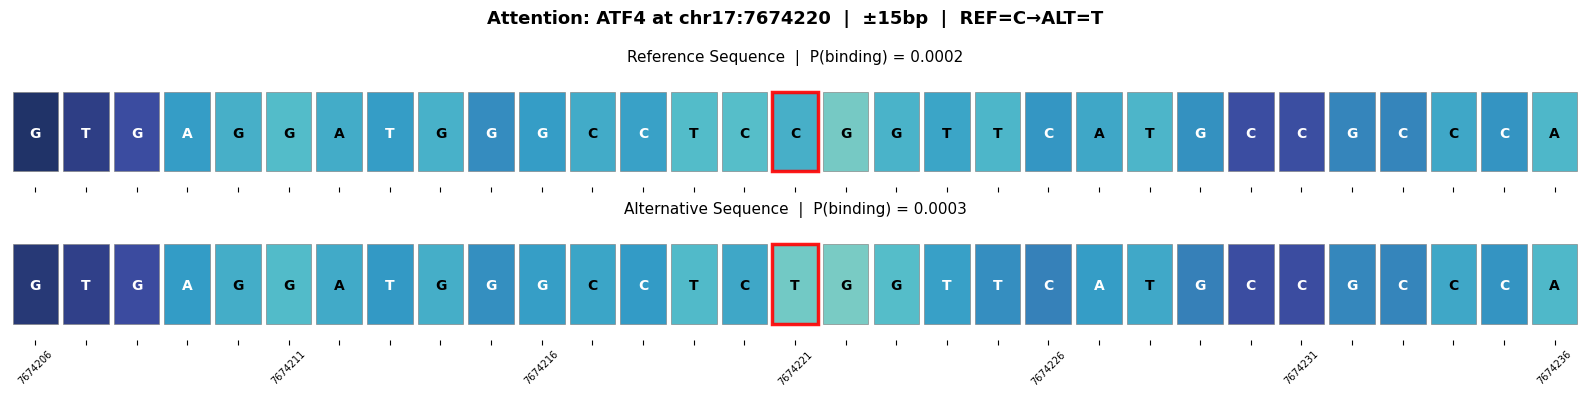

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Plot colored nucleotide attention for ATF4
fig = dvr.plot_sequence_attention("ATF4", window=15)

---
## Summary

| Feature | Method |
|---|---|
| Score with attention | `dvr.score_variant(..., return_attention=True)` |
| Summary metrics | DataFrame columns: `attention_score_change`, `max_attention_shift`, etc. |
| Position-level data | `dvr.get_attention("ATF4")` → dict with REF/ALT attention arrays |
| Bar chart plot | `dvr.plot_attention("ATF4", window=20)` |
| Layer heatmap | `dvr.plot_attention_heatmap("ATF4", window=20)` |
| Save plots | `dvr.plot_attention("ATF4", save_path="plot.png")` |
| Custom analysis | Use `attn["ref_raw"]` / `attn["alt_raw"]` numpy arrays directly |

**Key interpretability insight:** Unlike black-box variant effect predictors (e.g., AlphaGenome),
DeepVRegulome's attention mechanism directly reveals which sequence positions drive the model's
prediction change — enabling mechanistic interpretation of regulatory disruption.